In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES


In [2]:
from stn_gpe import *
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from scipy.signal import hilbert
import os
from scipy.signal import welch
from scipy.stats import entropy
from tqdm.autonotebook import tqdm
import pickle as pkl

/Users/charithapalika/Desktop/Lab projects/Labsystem/Rossler/ROSSLER_CLEANED_FILES/stn_gpe/analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
path = os.path.join(project_root,'params/stn_gpe_params/params_k.yaml') 
data = load_yaml(path)
omega =np.ones((data['N'],1))*data['omega']  

### Loop simulations

In [4]:
K_ARR = np.array([0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.65])

ENTROPY_MONITOR = []
PHASE_SYNC_MONITOR = []
APC_MONITOR = []
STD_MEAN_MONITOR = []

for k in tqdm(K_ARR, total=len(K_ARR), desc="Processing k values"):
    data['k'] = k
    RN = RosslerNetwork(N = data['N'], 
                    a = data['a'],
                    b = data['b'], 
                    c = data['c'], 
                    d = data['d'], 
                    k = data['k'],
                    omega= omega, 
                    Iext=data['Iext'])
    sol = RN.run()
    t_low = 200000
    t_high = 50000*10

    x_solved = np.array(sol.y[0:100,t_low:t_high]) 
    x_avg_signal =  np.mean(x_solved,0)

    # Entropy
    avg_entropy = spectral_entropy(signal=x_avg_signal,
                                   fs = 50000,
                                   nperseg = 100000,
                                   fmax = 50,
                                   normalize = True)
    ENTROPY_MONITOR.append(avg_entropy)

    # Phase Sync
    avg_phase_sync = phase_sync(signal=x_solved)
    PHASE_SYNC_MONITOR.append(avg_phase_sync)

    # APC
    avg_apc = APC(signal=x_solved)
    APC_MONITOR.append(avg_apc)

    # Average variance
    normalized_x_vals = 2 * (x_solved - np.min(x_solved))/(np.max(x_solved)-np.min(x_solved))
    x_mean = np.mean(normalized_x_vals,0)
    x_std = np.std(normalized_x_vals,0)
    STD_MEAN_MONITOR.append(np.mean(x_std))
    print(f'k:{k}, entropy:{avg_entropy}, phase_sync:{avg_phase_sync}, APC:{avg_apc}, Std :{np.mean(x_std)}')
    

Processing k values:   0%|          | 0/8 [00:00<?, ?it/s]

k:0.25, entropy:0.1905563711661767, phase_sync:1.0, APC:0.9999999999999999, Std :5.450909501464426e-14
k:0.3, entropy:0.1922970699610138, phase_sync:1.0, APC:0.9999999999999979, Std :2.7099863506020027e-11
k:0.35, entropy:0.21173369205391376, phase_sync:0.9999999999999973, APC:0.9999999999999942, Std :1.1453530963421674e-08
k:0.4, entropy:0.2010642615820025, phase_sync:0.9960978888075197, APC:0.9647434810996919, Std :0.08358548419135542
k:0.45, entropy:0.2032996346315765, phase_sync:0.9689746016749122, APC:0.8894040167269326, Std :0.16735765560686508
k:0.5, entropy:0.6549904544056933, phase_sync:0.12125640494306182, APC:-0.00305793148219157, Std :0.38982963070189464
k:0.55, entropy:0.7917217867111758, phase_sync:0.13553248590856265, APC:0.02851280616475958, Std :0.43247870398636507
k:0.65, entropy:0.8426586159390168, phase_sync:0.10143170331756851, APC:-0.02150524738749802, Std :0.41408179314410937


### Saving data

In [5]:
DICT_ALL = {'APC': APC_MONITOR,
            'ENTROPY': ENTROPY_MONITOR,
            'PHASE_SYNC': PHASE_SYNC_MONITOR,
            'STD_MEAN': STD_MEAN_MONITOR,
            'k': K_ARR}

In [ ]:
# save dictionary as pickle
folder_name = 'temp/k'
folder_path = project_root + '/' + folder_name
# create a temp folder in root base folder
os.makedirs(folder_path, exist_ok=True)


file_name = 'k_loop_runs'
with open(folder_path + '/' + file_name + '.pkl', 'wb') as handle:
    pkl.dump(DICT_ALL, handle)

### Reading pickle file

In [7]:
# read dictionary from pickle
with open(folder_path + '/' +file_name + '.pkl', 'rb') as handle:
    DICT_ALL = pkl.load(handle)
    print(DICT_ALL.keys())

dict_keys(['APC', 'ENTROPY', 'PHASE_SYNC', 'STD_MEAN', 'k'])


### Plotting data

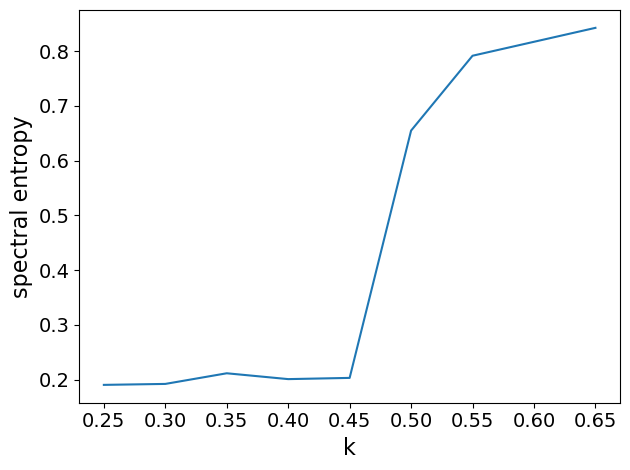

In [11]:
# plot entropy
k_arr = DICT_ALL['k']
entropy_arr = DICT_ALL['ENTROPY']
plt.plot(k_arr, entropy_arr)
plt.xlabel('k', fontsize=16, fontweight = 530)
plt.ylabel('spectral entropy', fontsize=16, fontweight = 530)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

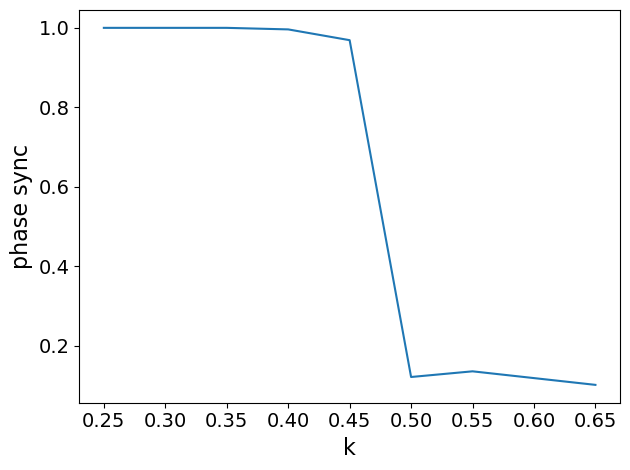

In [12]:
# plot phase sync
k_arr = DICT_ALL['k']
phase_sync_arr = DICT_ALL['PHASE_SYNC']
plt.plot(k_arr, phase_sync_arr)
plt.xlabel('k', fontsize=16, fontweight = 530)
plt.ylabel('phase sync', fontsize=16, fontweight = 530)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

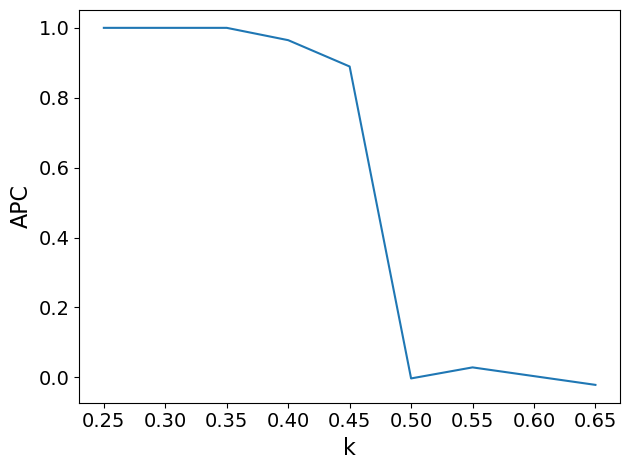

In [13]:
# plot APC
k_arr = DICT_ALL['k']
APC_arr = DICT_ALL['APC']
plt.plot(k_arr, APC_arr)
plt.xlabel('k', fontsize=16, fontweight = 530)
plt.ylabel('APC', fontsize=16, fontweight = 530)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()